<a href="https://colab.research.google.com/github/ranjanmitra/AIML-Gen-AI-Projects/blob/main/Activation_Function_%26_Regularization_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Let's compare Lasso (L1 Regularization) and Ridge (L2 Regularization) in Python using a simple dataset.

Key Features in This Model:
- Softmax Activation in Output Layer
- Converts logits into probabilities (useful for multi-class classification).
- Ensures sum of probabilities = 1 for valid predictions.
- Dropout Regularization in Hidden Layers
- Dropout(0.2) randomly removes 20% of neurons during training to prevent overfitting.
- Helps generalize better to unseen data.
- ReLU Activation in Hidden Layers
- Ensures efficient learning without vanishing gradient issues.
- Works better than Sigmoid/Tanh in deep models.
Expected Outcome:
- The Test Accuracy should be around 98% for handwritten digit recognition.
- Dropout ensures the model doesn’t overfit to training data.
Would you like to visualize training performance or explore hyperparameter tuning? 🚀


In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Sample dataset
data = {
    "Square_Feet": [750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200],
    "Bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    "Age": [10, 8, 12, 15, 5, 7, 20, 18, 3, 4],
    "Price": [150, 160, 170, 180, 190, 200, 210, 220, 230, 240]  # Hypothetical house prices in $K
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Define independent (X) and dependent (y) variables
X = df.drop(columns=["Price"])
y = df["Price"]

# Standardize features (important for regularization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize Lasso and Ridge models
lasso = Lasso(alpha=0.1)  # L1 regularization
ridge = Ridge(alpha=0.1)  # L2 regularization

# Fit models
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Predict on test set
lasso_preds = lasso.predict(X_test)
ridge_preds = ridge.predict(X_test)

# Evaluate models
lasso_mse = mean_squared_error(y_test, lasso_preds)
ridge_mse = mean_squared_error(y_test, ridge_preds)

print(f"Lasso MSE: {lasso_mse}")
print(f"Ridge MSE: {ridge_mse}")

# Compare coefficients
print("\nLasso Coefficients:", lasso.coef_)
print("Ridge Coefficients:", ridge.coef_)

Lasso MSE: 0.010047467772770045
Ridge MSE: 4.050277302750876

Lasso Coefficients: [28.62275135  0.         -0.        ]
Ridge Coefficients: [23.5842625   5.58036091 -0.04385821]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


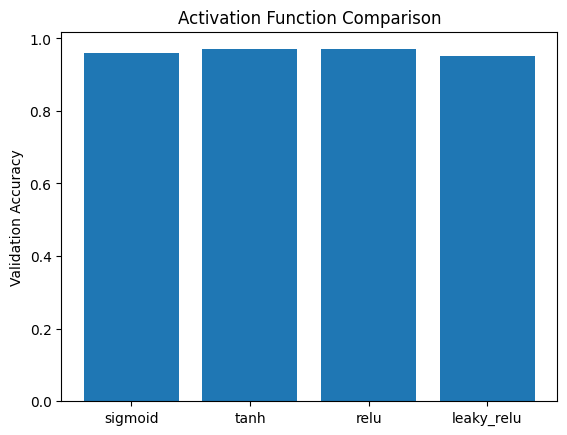

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Generate synthetic dataset
np.random.seed(42)
X = np.random.randn(500, 2)  # Features
y = (X[:, 0] + X[:, 1] > 0).astype(int)  # Binary labels based on sum of features

# Define activation functions to compare
activations = ["sigmoid", "tanh", "relu", "leaky_relu"]

# Store results
results = {}

for activation in activations:
    # Build a simple neural network
    model = Sequential([
        Dense(10, activation=activation, input_shape=(2,)),
        Dense(1, activation="sigmoid")  # Binary classification output
    ])

    # Compile model
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    # Train model
    history = model.fit(X, y, epochs=50, verbose=0, validation_split=0.2)

    # Store accuracy
    results[activation] = history.history["val_accuracy"][-1]

# Plot results
plt.bar(results.keys(), results.values())
plt.ylabel("Validation Accuracy")
plt.title("Activation Function Comparison")
plt.show()

We’ll classify handwritten digits (0-9) using a deep neural network with:
- Softmax activation in the output layer (for multi-class classification).
- Dropout regularization in hidden layers (to prevent overfitting)
Key Features in This Model:
- Softmax Activation in Output Layer
- Converts logits into probabilities (useful for multi-class classification).
- Ensures sum of probabilities = 1 for valid predictions.
- Dropout Regularization in Hidden Layers
- Dropout(0.2) randomly removes 20% of neurons during training to prevent overfitting.
- Helps generalize better to unseen data.
- ReLU Activation in Hidden Layers
- Ensures efficient learning without vanishing gradient issues.
- Works better than Sigmoid/Tanh in deep models.
Expected Outcome:
- The Test Accuracy should be around 98% for handwritten digit recognition.
- Dropout ensures the model doesn’t overfit to training data.
Would you like to visualize training performance or explore hyperparameter tuning? 🚀


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset (handwritten digits 0-9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values (scale between 0 and 1)
X_train, X_test = X_train / 255.0, X_test / 255.0

# Flatten images (28x28 -> 784 features)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Convert labels to one-hot encoding (for Softmax output)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build Neural Network model
model = Sequential([
    Dense(512, activation="relu", input_shape=(784,)),  # Hidden layer with ReLU
    Dropout(0.2),  # Regularization to prevent overfitting
    Dense(256, activation="relu"),  # Second hidden layer
    Dropout(0.2),  # More regularization
    Dense(10, activation="softmax")  # Multi-class output layer (Softmax)
])

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), verbose=1)

# Evaluate model accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8831 - loss: 0.3731 - val_accuracy: 0.9682 - val_loss: 0.0966
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9671 - loss: 0.1071 - val_accuracy: 0.9737 - val_loss: 0.0903
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9748 - loss: 0.0802 - val_accuracy: 0.9783 - val_loss: 0.0713
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9795 - loss: 0.0652 - val_accuracy: 0.9779 - val_loss: 0.0773
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9802 - loss: 0.0599 - val_accuracy: 0.9785 - val_loss: 0.0704
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9855 - loss: 0.0446 - val_accuracy: 0.9797 - val_loss: 0.0726
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9852 - loss: 0.0462 - val_accuracy: 0.9803 - val_loss: 0.0700
Epoch 8/10
1875/1875 ━━━━━━━━

Plot Training & Validation Accuracy Over Epochs
We’ll track how accuracy evolves during training to detect overfitting


In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy and loss history
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(train_acc) + 1)

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, "bo-", label="Training Accuracy")
plt.plot(epochs, val_acc, "r*-", label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "r*-", label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

Hyperparameter Tuning Strategies
To improve the model further, tweak these parameters:
✅ Dropout Rate: Test Dropout(0.3) instead of Dropout(0.2) for stronger regularization.
✅ Learning Rate: Lower the learning rate in the Adam optimizer (tf.keras.optimizers.Adam(learning_rate=0.001)).
✅ Hidden Layers: Try increasing neurons (e.g., Dense(1024) instead of Dense(512)).
✅ Epochs: If validation loss is still improving at the final epoch, increase to 20 epochs.


In [11]:
pip install tensorflow scikit-learn


In [12]:
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import keras

In [2]:
pip install scikeras

In [5]:
pip install --upgrade scikit-learn

How Does This Work?
✔ Creates multiple models with different hyperparameter combinations.
✔ Tests each model using cross-validation (cv=3).
✔ Finds the best combination that maximizes validation accuracy.



In [2]:
!pip uninstall -y scikit-learn scikeras tensorflow
!pip install scikit-learn==1.3.2 scikeras==0.11.3 tensorflow==2.15.0


import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

# Load MNIST dataset (handwritten digits)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values (scale between 0 and 1)
X_train, X_test = X_train / 255.0, X_test / 255.0

# Flatten images (28x28 → 784 features)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Define model function for Grid Search
def create_model(learning_rate=0.001, dropout_rate=0.2, neurons=512):
    model = Sequential([
        Dense(neurons, activation="relu", input_shape=(784,)),
        Dropout(dropout_rate),
        Dense(neurons // 2, activation="relu"),
        Dropout(dropout_rate),
        Dense(10, activation="softmax")
    ])

    # Compile model with Adam optimizer
    model.compile(optimizer=Adam(learning_rate),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    return model

# Wrap model inside KerasClassifier
# Pass build_fn as build in scikeras version 0.5.0 and later
model = KerasClassifier(build=create_model, verbose=0)

# Define hyperparameter grid
param_grid = {
    "learning_rate": [0.001, 0.01, 0.1],      # Learning rate variations
    "dropout_rate": [0.2, 0.3, 0.4],         # Dropout percentage for regularization
    "neurons": [512, 1024],                  # Number of neurons in the first hidden layer
    # These parameters need to be passed to the KerasClassifier, not GridSearchCV directly
    # We will pass them as parameters to the KerasClassifier initialization or during fit
    # "batch_size": [32, 64],
    # "epochs": [10, 20]
}

# Initialize GridSearchCV
# Pass batch_size and epochs as parameters to the KerasClassifier during initialization
# or within the param_grid, but they need to be parameters of the KerasClassifier,
# not the GridSearchCV fit method.
# Based on scikeras documentation, batch_size and epochs are parameters of KerasClassifier.
# Let's include them in the param_grid and ensure the KerasClassifier is updated to accept them.
param_grid = {
    "learning_rate": [0.001, 0.01, 0.1],
    "dropout_rate": [0.2, 0.3, 0.4],
    "neurons": [512, 1024],
    "batch_size": [32, 64],
    "epochs": [10, 20]
}

# Re-initialize GridSearchCV with the updated parameter grid
# KerasClassifier correctly handles batch_size and epochs as its parameters.
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring="accuracy")

# Run Grid Search
grid.fit(X_train, y_train)

# Print best hyperparameter combination
print(f"Best Hyperparameters: {grid.best_params_}")
print(f"Best Validation Accuracy: {grid.best_score_:.4f}")

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: scikeras 0.13.0
Uninstalling scikeras-0.13.0:
  Successfully uninstalled scikeras-0.13.0
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
ERROR: Ignored the following versions that require a different python version: 0.10.0 Requires-Python >=3.7.0,<3.11.0; 0.2.0 Requires-Python >=3.6.7,<3.9; 0.2.1 Requires-Python >=3.6.7,<3.9; 0.6.0 Requires-Python >=3.7.0,<3.10.0; 0.6.1 Requires-Python >=3.7.0,<3.10.0; 0.7.0 Requires-Python >=3.7.0,<3.10.0; 0.8.0 Requires-Python >=3.7.0,<3.11.0; 0.9.0 Requires-Python >=3.7.0,<3.11.0
ERROR: Could not find a version that satisfies the requirement scikeras==0.11.3 (from versions: 0.1.6, 0.1.7, 0.1.8, 0.3.0, 0.3.1, 0.3.3, 0.4.0, 0.4.1, 0.11.0, 0.12.0, 0.13.0)
ERROR: No matching distribution found for scikeras==0.11.3


AttributeError: 'super' object has no attribute '__sklearn_tags__'